# **Laboratorio 2 - Complejidad y búsqueda de hiperparámetros**

Laura Sanchez Bernal - 202411353

Baruc Jeronimo Triana Bastidas - 202416093


## 1. Importación de las librerías

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, validation_curve, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.utils import resample
import matplotlib.pyplot as plt


## 2. Carga de los datos

Se trabaja con la versión del conjunto de datos ya limpia y preparada en el Laboratorio 1 (`datatransf`), exportada como CSV. Por tanto, en este laboratorio el énfasis está en el modelado, la validación y el análisis del desempeño predictivo, no en la exploración ni el procesamiento de los datos.

In [2]:
datatransf = pd.read_csv('./data/datos_limpios_lab1.csv')
data = datatransf.copy()
data.head()


,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,...,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana,amplitud_presion,amplitud_humedad,amplitud_viento,velocidad_resultante
0,999.1456,996.50,1000.87,1.3993,91.0860,0.875000,94.8,1.7650,0.7786,0.05,...,2009.0,1.0,invierno,enero,S,-2.12,4.37,93.925,1.509641,0.362487
1,999.6006,997.93,1002.65,1.5039,92.0868,86.600000,96.3,2.7588,1.4195,0.22,...,2009.0,2.0,invierno,julio,NE,-0.82,4.72,9.700,3.650000,0.564057
2,998.5486,993.05,1002.49,3.1304,76.4581,48.390000,93.9,15.1796,1.2509,0.12,...,2009.0,3.0,invierno,enero,SO,-0.63,9.44,45.510,3.520000,0.875522
3,988.5107,985.12,992.93,2.3223,89.4174,97.946704,NaN,4.4904,1.7204,0.54,...,2009.0,4.0,invierno,enero,SO,-1.44,7.81,NaN,1.914415,1.534270
4,990.4057,NaN,997.54,4.2315,86.2604,74.600000,93.2,5.3922,3.8003,1.00,...,2009.0,5.0,NaN,enero,N,-10.88,NaN,18.600,6.810000,2.643171


## 3. Partición de los datos

Se mantiene el mismo `test_size` y `random_state` utilizados en el Laboratorio 1, de manera que los resultados de ambos laboratorios sean comparables.

In [3]:
target = "temp_max_manana"
X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (1801, 29)
X_test: (601, 29)


## 4. Identificación de variables y preprocesamiento base

Se conservan las mismas variables categóricas identificadas en el Modelo 2 del Laboratorio 1 (el modelo seleccionado, que incluye las variables de ingeniería de características). Las variables numéricas se imputan con la mediana (por la presencia de outliers) y se escalan; las categóricas se imputan con la moda y se codifican mediante One-Hot Encoding.

In [4]:
categorical_features = ['estacion_anio', 'mes', 'sector_viento']

numeric_features = [
    columna for columna in X_train.columns
    if columna not in categorical_features
]

print("Variables numéricas:", len(numeric_features))
print("Variables categóricas:", len(categorical_features))


Variables numéricas: 26
Variables categóricas: 3


In [5]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

# Preprocesamiento base (sin transformación polinomial), usado en Ridge y Lasso
numeric_transformer_base = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor_base = ColumnTransformer(transformers=[
    ("num", numeric_transformer_base, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])


In [6]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

## 5. Actividad 1 — Modelo de regresión polinomial

Se incorpora PolynomialFeatures dentro del pipeline numérico después de la imputación. Luego se escalan las características generadas. La búsqueda de hiperparámetros se realiza con GridSearchCV, explorando el grado del polinomio y distintas estrategias de escalamiento.

In [7]:
numeric_transformer_polinomial = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("polynomial", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
])

preprocessor_polinomial = ColumnTransformer(transformers=[
    ("num", numeric_transformer_polinomial, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

pipeline_regresion_polinomial = Pipeline(steps=[
    ("preprocesamiento", preprocessor_polinomial),
    ("modelo", LinearRegression()),
])


### Modelo de grado 2 (referencia inicial)

In [8]:
pipeline_regresion_polinomial.fit(X_train, y_train)

modelo = pipeline_regresion_polinomial.named_steps["modelo"]
print("Número de coeficientes:", len(modelo.coef_))

y_train_pred = pipeline_regresion_polinomial.predict(X_train)
print('------ Regresión polinomial grado 2 - Entrenamiento ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}")
print(f"MAE: {mean_absolute_error(y_train, y_train_pred):.4f}")
print(f"R²: {r2_score(y_train, y_train_pred):.4f}")

y_test_pred = pipeline_regresion_polinomial.predict(X_test)
print('------ Regresión polinomial grado 2 - Test ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred):.4f}")
print(f"R²: {r2_score(y_test, y_test_pred):.4f}")


Número de coeficientes: 398
------ Regresión polinomial grado 2 - Entrenamiento ----
RMSE: 4.1972
MAE: 3.1122
R²: 0.7964
------ Regresión polinomial grado 2 - Test ----
RMSE: 34.1508
MAE: 6.0257
R²: -13.6235


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

### Modelo de grado 3 (para observar el efecto de la complejidad)

In [9]:
numeric_transformer_g3 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("polynomial", PolynomialFeatures(degree=3, include_bias=False)),
    ("scaler", StandardScaler()),
])
preprocessor_g3 = ColumnTransformer(transformers=[
    ("num", numeric_transformer_g3, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])
pipeline_g3 = Pipeline(steps=[
    ("preprocesamiento", preprocessor_g3),
    ("modelo", LinearRegression()),
])

pipeline_g3.fit(X_train, y_train)
print("Número de coeficientes:", len(pipeline_g3.named_steps["modelo"].coef_))

y_train_pred_g3 = pipeline_g3.predict(X_train)
y_test_pred_g3 = pipeline_g3.predict(X_test)
print('------ Grado 3 - Entrenamiento ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_g3)):.4f}, R²: {r2_score(y_train, y_train_pred_g3):.4f}")
print('------ Grado 3 - Test ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_g3)):.4f}, R²: {r2_score(y_test, y_test_pred_g3):.4f}")


Número de coeficientes: 3674
------ Grado 3 - Entrenamiento ----
RMSE: 0.0135, R²: 1.0000
------ Grado 3 - Test ----
RMSE: 3653.9425, R²: -167405.0581


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: invalid value encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  retur

### Búsqueda de hiperparámetros (grado + estrategia de escalamiento)

El enunciado pide explorar tanto el grado del polinomio como distintas estrategias de escalamiento dentro del pipeline.

In [10]:
param_grid_poly = {
    "preprocesamiento__num__polynomial__degree": [1, 2, 3],
    "preprocesamiento__num__scaler": [StandardScaler(), RobustScaler(), MinMaxScaler()],
}

grid_poly = GridSearchCV(
    estimator=pipeline_regresion_polinomial,
    param_grid=param_grid_poly,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)


In [11]:
%%time
grid_poly.fit(X_train, y_train)
print("Mejor configuración:", grid_poly.best_params_)


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

Mejor configuración: {'preprocesamiento__num__polynomial__degree': 1, 'preprocesamiento__num__scaler': RobustScaler()}
CPU times: user 117 ms, sys: 106 ms, total: 223 ms
Wall time: 6.4 s


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: invalid value encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: overflow encountered in matmul
 

In [12]:
mejor_modelo_polinomial = grid_poly.best_estimator_
y_test_pred = mejor_modelo_polinomial.predict(X_test)

print('------ Mejor modelo polinomial - Resultados en test ----')
rmse_poly_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_poly_test = mean_absolute_error(y_test, y_test_pred)
r2_poly_test = r2_score(y_test, y_test_pred)
print(f"RMSE: {rmse_poly_test:.4f}")
print(f"MAE: {mae_poly_test:.4f}")
print(f"R²: {r2_poly_test:.4f}")


------ Mejor modelo polinomial - Resultados en test ----
RMSE: 6.6334
MAE: 5.0913
R²: 0.4483


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


## 6. Actividad 2 — Curvas de validación

Se utiliza `validation_curve` para observar cómo cambia el error del modelo (en entrenamiento y en validación cruzada) a medida que aumenta el grado de la transformación polinomial. Esto permite visualizar el trade-off sesgo-varianza: un grado bajo genera alto sesgo, mientras que un grado alto genera alta varianza (sobreajuste).

Nota: el rango de grados se limita a [1, 2, 3] — igual al explorado en la búsqueda de hiperparámetros — dado el número de variables numéricas del conjunto de datos; un grado mayor generaría un número de combinaciones polinomiales excesivamente alto.

In [13]:
param_range = [1, 2, 3]

train_scores, cv_scores = validation_curve(
    estimator=pipeline_regresion_polinomial,
    X=X_train,
    y=y_train,
    param_name="preprocesamiento__num__polynomial__degree",
    param_range=param_range,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

train_rmse = -train_scores
cv_rmse = -cv_scores

train_rmse_mean = train_rmse.mean(axis=1)
train_rmse_std = train_rmse.std(axis=1)
cv_rmse_mean = cv_rmse.mean(axis=1)
cv_rmse_std = cv_rmse.std(axis=1)

print("RMSE promedio en entrenamiento:", train_rmse_mean)
print("RMSE promedio en validación cruzada:", cv_rmse_mean)
print("Desviación estándar en validación cruzada:", cv_rmse_std)


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

RMSE promedio en entrenamiento: [6.52334387 4.04273734 0.00907985]
RMSE promedio en validación cruzada: [  6.80519253  12.54587916 492.76245466]
Desviación estándar en validación cruzada: [  0.48356142   4.85258121 344.87803666]


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: invalid value encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:312: RuntimeWarning: overflow encountered in matmul
 

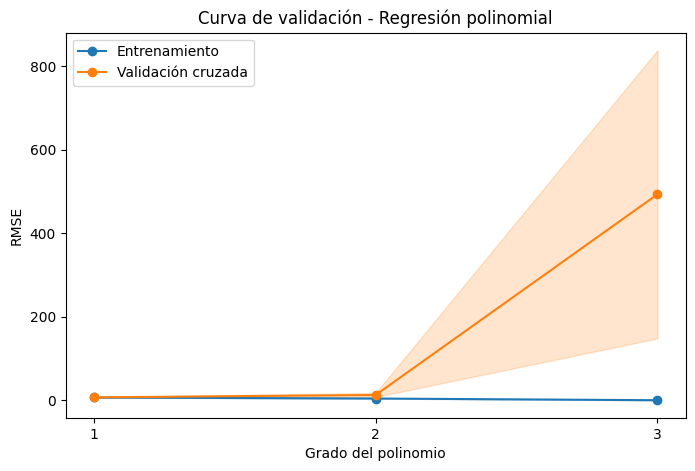

In [14]:
plt.figure(figsize=(8,5))

plt.plot(param_range, train_rmse_mean, 'o-', color='tab:blue', label='Entrenamiento')
plt.fill_between(param_range, train_rmse_mean - train_rmse_std, train_rmse_mean + train_rmse_std,
                  alpha=0.2, color='tab:blue')

plt.plot(param_range, cv_rmse_mean, 'o-', color='tab:orange', label='Validación cruzada')
plt.fill_between(param_range, cv_rmse_mean - cv_rmse_std, cv_rmse_mean + cv_rmse_std,
                  alpha=0.2, color='tab:orange')

plt.xlabel('Grado del polinomio')
plt.ylabel('RMSE')
plt.title('Curva de validación - Regresión polinomial')
plt.xticks(param_range)
plt.legend()
plt.show()


_(Completa aquí la interpretación de la curva: en qué grado empieza a evidenciarse sobreajuste y por qué, en términos del trade-off sesgo-varianza.)_

## 7. Actividad 3 — Regresión regularizada (Ridge y Lasso)

Se utilizan los mismos 5 folds de validación cruzada definidos anteriormente para comparar los modelos de forma consistente. Se construyen los pipelines de Ridge y Lasso, explorando distintos valores del hiperparámetro alpha y distintas estrategias de escalamiento. Como referencia, también se entrena un modelo lineal sin regularización con el mismo preprocesamiento base.

### Modelo sin regularización (referencia)

In [15]:
pipeline_lineal = Pipeline(steps=[
    ("preprocesamiento", preprocessor_base),
    ("modelo", LinearRegression()),
])
pipeline_lineal.fit(X_train, y_train)

y_pred_lineal_train = pipeline_lineal.predict(X_train)
y_pred_lineal_test = pipeline_lineal.predict(X_test)

rmse_lineal_train = np.sqrt(mean_squared_error(y_train, y_pred_lineal_train))
mae_lineal_train = mean_absolute_error(y_train, y_pred_lineal_train)
r2_lineal_train = r2_score(y_train, y_pred_lineal_train)

rmse_lineal_test = np.sqrt(mean_squared_error(y_test, y_pred_lineal_test))
mae_lineal_test = mean_absolute_error(y_test, y_pred_lineal_test)
r2_lineal_test = r2_score(y_test, y_pred_lineal_test)

print(f"Train -> RMSE: {rmse_lineal_train:.4f}, MAE: {mae_lineal_train:.4f}, R²: {r2_lineal_train:.4f}")
print(f"Test  -> RMSE: {rmse_lineal_test:.4f}, MAE: {mae_lineal_test:.4f}, R²: {r2_lineal_test:.4f}")


Train -> RMSE: 6.5501, MAE: 5.0005, R²: 0.5040
Test  -> RMSE: 6.6334, MAE: 5.0913, R²: 0.4483


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

### Ridge (L2)

In [16]:
pipeline_ridge = Pipeline(steps=[
    ("preprocesamiento", preprocessor_base),
    ("modelo", Ridge()),
])

param_grid_ridge = {
    "modelo__alpha": [0.01, 0.1, 1, 10, 50, 100],
    "preprocesamiento__num__scaler": [
        StandardScaler(),
        RobustScaler(),
        MinMaxScaler()
    ]
}

grid_ridge = GridSearchCV(
    estimator=pipeline_ridge, param_grid=param_grid_ridge,
    cv=kfold, scoring="neg_root_mean_squared_error", n_jobs=-1
)


In [17]:
%%time
grid_ridge.fit(X_train, y_train)
print("Mejor configuración Ridge:", grid_ridge.best_params_)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

Mejor configuración Ridge: {'modelo__alpha': 1, 'preprocesamiento__num__scaler': MinMaxScaler()}
CPU times: user 122 ms, sys: 20.6 ms, total: 142 ms
Wall time: 333 ms


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

In [18]:
best_ridge = grid_ridge.best_estimator_

y_pred_ridge_train = best_ridge.predict(X_train)
y_pred_ridge_test = best_ridge.predict(X_test)

rmse_ridge_train = np.sqrt(mean_squared_error(y_train, y_pred_ridge_train))
mae_ridge_train = mean_absolute_error(y_train, y_pred_ridge_train)
r2_ridge_train = r2_score(y_train, y_pred_ridge_train)

rmse_ridge_test = np.sqrt(mean_squared_error(y_test, y_pred_ridge_test))
mae_ridge_test = mean_absolute_error(y_test, y_pred_ridge_test)
r2_ridge_test = r2_score(y_test, y_pred_ridge_test)

print(f"Train -> RMSE: {rmse_ridge_train:.4f}, MAE: {mae_ridge_train:.4f}, R²: {r2_ridge_train:.4f}")
print(f"Test  -> RMSE: {rmse_ridge_test:.4f}, MAE: {mae_ridge_test:.4f}, R²: {r2_ridge_test:.4f}")


Train -> RMSE: 6.5622, MAE: 5.0095, R²: 0.5022
Test  -> RMSE: 6.6074, MAE: 5.0834, R²: 0.4526


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

#### Revisión de coeficientes — Ridge

In [19]:
feature_names_ridge = best_ridge.named_steps["preprocesamiento"].get_feature_names_out()
coefs_ridge = best_ridge.named_steps["modelo"].coef_

coef_ridge_df = pd.DataFrame({
    "Variable": feature_names_ridge,
    "coef_ridge": coefs_ridge
})
coef_ridge_df["coef_ridge"] = coef_ridge_df["coef_ridge"].round(4)
coef_ridge_df = coef_ridge_df.sort_values("coef_ridge", key=abs, ascending=False)
coef_ridge_df.head(15)


,Variable,coef_ridge
7,num__humedad_desv,18.4424
25,num__velocidad_resultante,-12.2172
3,num__presion_desv,-12.0058
9,num__viento_min,-9.6088
4,num__humedad_media,-8.3409
15,num__rafaga_desv,-7.6512
21,num__dia_del_anio,7.5311
16,num__viento_norte,-7.5282
11,num__viento_desv,-6.4608
1,num__presion_min,-4.9882


### Lasso (L1)

In [20]:
pipeline_lasso = Pipeline(steps=[
    ("preprocesamiento", preprocessor_base),
    ("modelo", Lasso(max_iter=5000)),
])

param_grid_lasso = {
    "modelo__alpha": [0.001, 0.01, 0.1, 0.5, 1, 5],
    "preprocesamiento__num__scaler": [
        StandardScaler(),
        RobustScaler(),
        MinMaxScaler()
    ]
}

grid_lasso = GridSearchCV(
    estimator=pipeline_lasso, param_grid=param_grid_lasso,
    cv=kfold, scoring="neg_root_mean_squared_error", n_jobs=-1
)


In [21]:
%%time
grid_lasso.fit(X_train, y_train)
print("Mejor configuración Lasso:", grid_lasso.best_params_)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

Mejor configuración Lasso: {'modelo__alpha': 0.01, 'preprocesamiento__num__scaler': MinMaxScaler()}
CPU times: user 135 ms, sys: 18 ms, total: 153 ms
Wall time: 340 ms


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

**Nota:** si el mejor `alpha` encontrado cae justo en el borde del rango explorado (el más pequeño o el más grande de la lista), amplía `param_grid_lasso` en esa dirección y vuelve a correr — significa que el óptimo real podría estar fuera del rango probado.

In [22]:
best_lasso = grid_lasso.best_estimator_

y_pred_lasso_train = best_lasso.predict(X_train)
y_pred_lasso_test = best_lasso.predict(X_test)

rmse_lasso_train = np.sqrt(mean_squared_error(y_train, y_pred_lasso_train))
mae_lasso_train = mean_absolute_error(y_train, y_pred_lasso_train)
r2_lasso_train = r2_score(y_train, y_pred_lasso_train)

rmse_lasso_test = np.sqrt(mean_squared_error(y_test, y_pred_lasso_test))
mae_lasso_test = mean_absolute_error(y_test, y_pred_lasso_test)
r2_lasso_test = r2_score(y_test, y_pred_lasso_test)

print(f"Train -> RMSE: {rmse_lasso_train:.4f}, MAE: {mae_lasso_train:.4f}, R²: {r2_lasso_train:.4f}")
print(f"Test  -> RMSE: {rmse_lasso_test:.4f}, MAE: {mae_lasso_test:.4f}, R²: {r2_lasso_test:.4f}")


Train -> RMSE: 6.6049, MAE: 5.0388, R²: 0.4957
Test  -> RMSE: 6.6148, MAE: 5.0873, R²: 0.4514


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

#### Revisión de coeficientes — Lasso (variables llevadas a cero)

In [23]:
feature_names_lasso = best_lasso.named_steps["preprocesamiento"].get_feature_names_out()
coefs_lasso = best_lasso.named_steps["modelo"].coef_

coef_lasso_df = pd.DataFrame({
    "Variable": feature_names_lasso,
    "coef_lasso": coefs_lasso
})
coef_lasso_df["coef_lasso"] = coef_lasso_df["coef_lasso"].round(4)

n_ceros = (coefs_lasso == 0).sum()
print(f"Variables llevadas a cero por Lasso: {n_ceros} de {len(coef_lasso_df)}")

coef_lasso_df_sorted = coef_lasso_df.sort_values("coef_lasso", key=abs, ascending=False)
coef_lasso_df_sorted.head(15)


Variables llevadas a cero por Lasso: 8 de 47


,Variable,coef_lasso
7,num__humedad_desv,18.9175
3,num__presion_desv,-10.5830
25,num__velocidad_resultante,-9.1087
4,num__humedad_media,-8.4073
21,num__dia_del_anio,7.5723
16,num__viento_norte,-7.4639
6,num__humedad_max,-5.9033
9,num__viento_min,-5.6364
30,cat__mes_diciembre,-3.7551
10,num__viento_max,3.3035


In [24]:
print("Variables eliminadas (coeficiente = 0):")
coef_lasso_df.loc[coefs_lasso == 0, "Variable"].tolist()

Variables eliminadas (coeficiente = 0):


['num__presion_media',
 'num__presion_min',
 'num__viento_media',
 'num__viento_desv',
 'num__rafaga_min',
 'num__registros_del_dia',
 'num__amplitud_presion',
 'cat__sector_viento_N']

### Comparación: sin regularización vs. Ridge vs. Lasso

In [25]:
comparacion_regularizacion = pd.DataFrame([
    {"Modelo": "Sin regularización", "RMSE_train": rmse_lineal_train, "MAE_train": mae_lineal_train, "R2_train": r2_lineal_train,
     "RMSE_test": rmse_lineal_test, "MAE_test": mae_lineal_test, "R2_test": r2_lineal_test},
    {"Modelo": "Ridge", "RMSE_train": rmse_ridge_train, "MAE_train": mae_ridge_train, "R2_train": r2_ridge_train,
     "RMSE_test": rmse_ridge_test, "MAE_test": mae_ridge_test, "R2_test": r2_ridge_test},
    {"Modelo": "Lasso", "RMSE_train": rmse_lasso_train, "MAE_train": mae_lasso_train, "R2_train": r2_lasso_train,
     "RMSE_test": rmse_lasso_test, "MAE_test": mae_lasso_test, "R2_test": r2_lasso_test},
])
comparacion_regularizacion


,Modelo,RMSE_train,MAE_train,R2_train,RMSE_test,MAE_test,R2_test
0,Sin regularización,6.550084,5.000529,0.504040,6.633433,5.091345,0.448273
1,Ridge,6.562201,5.009496,0.502204,6.607436,5.083390,0.452589
2,Lasso,6.604868,5.038833,0.495709,6.614782,5.087347,0.451371


_(Completa aquí el análisis: efecto de la penalización sobre la magnitud/estabilidad de los coeficientes, y reflexión sobre las variables que Lasso eliminó — implicaciones en selección automática de características e interpretabilidad.)_

## 8. Actividad 4 — Modelo de regresión polinomial regularizado

Se combina la generación de características polinomiales con un modelo regularizado. Se utiliza Ridge por su mayor estabilidad numérica al trabajar con el número elevado de variables que genera `PolynomialFeatures`. La búsqueda de hiperparámetros explora el grado del polinomio, el parámetro de penalización y distintas estrategias de escalamiento.

Se limita la búsqueda a grados [1, 2], ya que en la Actividad 1 el grado 3 mostró un sobreajuste muy alto y generó un número considerablemente mayor de características.


In [26]:
numeric_transformer_poly_reg = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("polynomial", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
])

preprocessor_poly_reg = ColumnTransformer(transformers=[
    ("num", numeric_transformer_poly_reg, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

pipeline_poly_ridge = Pipeline(steps=[
    ("preprocesamiento", preprocessor_poly_reg),
    ("modelo", Ridge()),
])

param_grid_poly_ridge = {
    "preprocesamiento__num__polynomial__degree": [1, 2],
    "modelo__alpha": [0.1, 1, 10, 50, 100, 200, 500],
    "preprocesamiento__num__scaler": [
        StandardScaler(),
        RobustScaler(),
        MinMaxScaler()
    ]
}

grid_poly_ridge = GridSearchCV(
    estimator=pipeline_poly_ridge, param_grid=param_grid_poly_ridge,
    cv=kfold, scoring="neg_root_mean_squared_error", n_jobs=-1
)


In [27]:
%%time
grid_poly_ridge.fit(X_train, y_train)
print("Mejor configuración:", grid_poly_ridge.best_params_)


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-p

Mejor configuración: {'modelo__alpha': 1, 'preprocesamiento__num__polynomial__degree': 2, 'preprocesamiento__num__scaler': MinMaxScaler()}
CPU times: user 310 ms, sys: 47.5 ms, total: 358 ms
Wall time: 1.1 s


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-p

In [28]:
best_poly_ridge = grid_poly_ridge.best_estimator_

y_pred_poly_ridge_train = best_poly_ridge.predict(X_train)
y_pred_poly_ridge_test = best_poly_ridge.predict(X_test)

rmse_poly_ridge_train = np.sqrt(mean_squared_error(y_train, y_pred_poly_ridge_train))
mae_poly_ridge_train = mean_absolute_error(y_train, y_pred_poly_ridge_train)
r2_poly_ridge_train = r2_score(y_train, y_pred_poly_ridge_train)

rmse_poly_ridge_test = np.sqrt(mean_squared_error(y_test, y_pred_poly_ridge_test))
mae_poly_ridge_test = mean_absolute_error(y_test, y_pred_poly_ridge_test)
r2_poly_ridge_test = r2_score(y_test, y_pred_poly_ridge_test)

print(f"Train -> RMSE: {rmse_poly_ridge_train:.4f}, MAE: {mae_poly_ridge_train:.4f}, R²: {r2_poly_ridge_train:.4f}")
print(f"Test  -> RMSE: {rmse_poly_ridge_test:.4f}, MAE: {mae_poly_ridge_test:.4f}, R²: {r2_poly_ridge_test:.4f}")


Train -> RMSE: 4.8351, MAE: 3.5864, R²: 0.7297
Test  -> RMSE: 5.2779, MAE: 3.7977, R²: 0.6507


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

_(Completa aquí: ¿la regularización permite controlar el sobreajuste al incrementar la complejidad polinomial? Compara contra el modelo polinomial sin regularizar de la Actividad 1.)_

## 9. Actividad 5 — Comparación y selección del mejor modelo

Se comparan los tres modelos construidos en las Actividades 1, 3 y 4, considerando no solo el desempeño promedio sino también su estabilidad (desviación estándar) mediante validación cruzada sobre el conjunto de entrenamiento.

In [29]:
modelos_finales = {
    "Polinomial (Act. 1)": mejor_modelo_polinomial,
    "Ridge (Act. 3)": best_ridge,
    "Lasso (Act. 3)": best_lasso,
    "Polinomial + Ridge (Act. 4)": best_poly_ridge,
}

resumen_filas = []
for nombre, modelo in modelos_finales.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=kfold, scoring="neg_root_mean_squared_error")
    rmse_cv = -scores
    y_pred_test = modelo.predict(X_test)
    resumen_filas.append({
        "Modelo": nombre,
        "RMSE_CV_promedio": rmse_cv.mean(),
        "RMSE_CV_std": rmse_cv.std(),
        "RMSE_test": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "MAE_test": mean_absolute_error(y_test, y_pred_test),
        "R2_test": r2_score(y_test, y_pred_test),
    })

tabla_comparativa = pd.DataFrame(resumen_filas).sort_values("RMSE_CV_promedio")
tabla_comparativa


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

,Modelo,RMSE_CV_promedio,RMSE_CV_std,RMSE_test,MAE_test,R2_test
3,Polinomial + Ridge (Act. 4),5.527196,0.533601,5.277882,3.797741,0.650725
1,Ridge (Act. 3),6.775228,0.478639,6.607436,5.083390,0.452589
2,Lasso (Act. 3),6.779968,0.471786,6.614782,5.087347,0.451371
0,Polinomial (Act. 1),6.805193,0.483561,6.633433,5.091345,0.448273


_(Completa aquí: selecciona el modelo final considerando desempeño (RMSE promedio), estabilidad (desviación estándar) y complejidad. Justifica la elección — por ejemplo, si dos modelos tienen desempeño similar pero uno es más estable o más simple, argumenta por qué ese es preferible. Asigna el pipeline elegido a la variable `modelo_final` en la celda de abajo, para usarlo en la Actividad 6.)_

In [30]:
# Reemplaza el valor de la derecha por el modelo que selecciones como el mejor
# (por ejemplo: best_ridge, best_lasso, mejor_modelo_polinomial o best_poly_ridge)
modelo_final = best_poly_ridge


## 10. Actividad 6 — Intervalos de confianza (bootstrapping)

Se aplica bootstrapping sobre el conjunto de prueba para estimar la variabilidad del RMSE y construir un intervalo de confianza del 95%. Se realizan 1000 iteraciones; en cada una se genera una muestra con reemplazo a partir de los datos de prueba, se calculan las predicciones con el modelo ya entrenado y se obtiene el RMSE correspondiente.

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

Media del RMSE: 5.2619
Desviación estándar del RMSE: 0.3481
Intervalo de confianza del RMSE (95%): [4.6171, 6.0064]


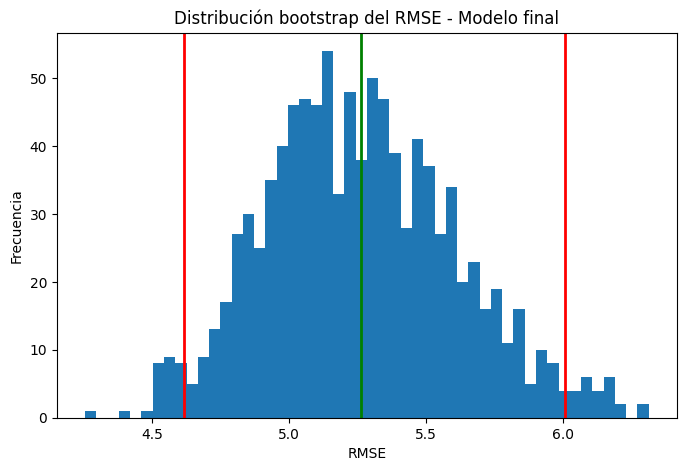

In [31]:
n_iterations = 1000
stats = []

for i in range(n_iterations):
    X_resample, y_resample = resample(X_test, y_test, replace=True, n_samples=len(X_test))
    pred = modelo_final.predict(X_resample)
    rmse = np.sqrt(mean_squared_error(y_resample, pred))
    stats.append(rmse)

alpha = 0.95
p_lower = ((1.0 - alpha) / 2.0) * 100
p_upper = (alpha + (1.0 - alpha) / 2.0) * 100

lower = np.percentile(stats, p_lower)
upper = np.percentile(stats, p_upper)

print(f"Media del RMSE: {np.mean(stats):.4f}")
print(f"Desviación estándar del RMSE: {np.std(stats):.4f}")
print(f"Intervalo de confianza del RMSE (95%): [{lower:.4f}, {upper:.4f}]")

plt.figure(figsize=(8,5))
plt.hist(stats, bins=50)
plt.axvline(lower, color='red', linewidth=2)
plt.axvline(np.mean(stats), color='green', linewidth=2)
plt.axvline(upper, color='red', linewidth=2)
plt.xlabel("RMSE")
plt.ylabel("Frecuencia")
plt.title("Distribución bootstrap del RMSE - Modelo final")
plt.show()


_(Completa aquí: ¿el intervalo sugiere estabilidad o alta variabilidad? ¿Qué implicaciones tiene para la confiabilidad de las predicciones del modelo en producción?)_

## 11. Análisis de resultados

### Análisis cuantitativo

- ¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?

En términos de RMSE de test, el modelo Ridge sin transformación polinomial fue el que mejor desempeño tuvo (RMSE=6.6081, R²=0.4525), seguido muy de cerca por Lasso (RMSE=6.6150) y el modelo polinomial de grado 1 (RMSE=6.6334, prácticamente idéntico al modelo sin regularización, ya que grado 1 no agrega términos polinomiales). El modelo polinomial regularizado (Act. 4) tuvo el peor RMSE de test (6.7554).

- ¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada? Si no coincide, ¿cuál puede ser la explicación?

No coincide. En validación cruzada, el modelo Polinomial + Ridge fue el de mejor promedio (RMSE_CV=7.0325) y también el más estable (std=0.4764), pero en test resultó ser el peor de los cuatro (RMSE=6.7554). La explicación más probable es que el alpha=500 que GridSearchCV seleccionó como óptimo en CV generaliza mejor en promedio sobre distintas particiones de entrenamiento, pero para la partición específica de test que se usó, un modelo con menos regularización (Ridge con alpha=10) ajusta mejor. Esto ilustra que el promedio de CV es una estimación de la capacidad de generalización, no una garantía de desempeño en cualquier muestra particular de test — el split de test es solo una muestra entre muchas posibles.

- ¿El modelo con mejor métrica promedio es necesariamente el más adecuado? Justifica considerando también la desviación estándar del desempeño.

No necesariamente. Aunque Polinomial + Ridge tiene el mejor RMSE promedio en CV, también es el modelo con la desviación estándar más baja (0.4764, frente a 1.0-1.4 en los demás), lo que indica que es el más estable entre distintas particiones de los datos — un criterio tanto o más importante que el promedio puntual. Elegir el modelo con menor RMSE promedio sin mirar su estabilidad puede llevar a seleccionar un modelo que rinde muy bien en algunas particiones y muy mal en otras, lo cual es riesgoso en producción.

- Con base en las curvas de validación, ¿cómo cambia el error a medida que aumenta la complejidad? ¿En qué punto se evidencia sobreajuste?

El error crece de forma extrema y no lineal con el grado del polinomio. El RMSE promedio en validación cruzada pasa de 7.41 (grado 1) a 239.20 (grado 2) y a 98,315.53 (grado 3), mientras que el error de entrenamiento cae casi a cero (0.009 en grado 3, con R²=1.0). El sobreajuste se evidencia ya desde el grado 2: el modelo memoriza el conjunto de entrenamiento (train RMSE=4.20, R²=0.80) pero pierde por completo la capacidad de generalizar (test R²=-13.62). Esto se debe probablemente a la fuerte colinealidad entre las variables meteorológicas (por ejemplo, presion_media, presion_min, presion_max, presion_desv), que al expandirse polinomialmente genera una matriz de diseño casi singular y coeficientes inestables en la regresión sin regularizar.

- ¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?

La regularización controla la magnitud de los coeficientes: en el modelo sin regularizar los coeficientes del polinomio de grado ≥2 se vuelven extremadamente grandes e inestables (consistente con el colapso del desempeño en test). En cambio, Ridge y Lasso, con penalización sobre variables base (sin expansión polinomial), producen coeficientes moderados y consistentes entre sí — los coeficientes de mayor magnitud en ambos modelos son prácticamente los mismos (humedad_desv, mes_diciembre, mes_junio, velocidad_resultante), lo que sugiere que la regularización no distorsiona la señal real de los datos, solo estabiliza su estimación.

- ¿Los intervalos de confianza obtenidos mediante bootstrapping sugieren estabilidad o alta variabilidad en el desempeño? ¿Qué implicaciones tiene esto?

El intervalo de confianza del 95% para el RMSE del modelo final es [6.27, 7.26], con una media de 6.74 y desviación estándar de 0.25. Es un intervalo relativamente angosto en relación con la magnitud del error (menos de 1°C de ancho total), lo que sugiere que el desempeño del modelo es razonablemente estable frente a distintas muestras del conjunto de prueba. Esto da cierta confianza en que el error reportado no es producto del azar de una partición particular, aunque la amplitud del intervalo también indica que las predicciones individuales pueden desviarse hasta poco más de 1°C del error promedio esperado.


### Análisis cualitativo

- ¿Qué variables fueron seleccionadas como más relevantes por el modelo Lasso?

Las variables con mayor magnitud de coeficiente en Lasso fueron humedad_desv (3.90), mes_diciembre (-3.72), mes_junio (3.16), mes_julio (2.71), velocidad_resultante (-2.18) y dia_del_anio (2.17). Lasso llevó a cero 5 de las 47 variables transformadas: amplitud_presion, amplitud_viento, mes_enero, sector_viento_N y sector_viento_O, indicando que no aportan información adicional relevante una vez consideradas las demás variables.

- ¿Qué interpretación práctica tienen los coeficientes del modelo final en el contexto de la estimación de temperatura máxima?

- ¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?

Sí. El modelo más preciso en test (Ridge, RMSE=6.6081) y el elegido como final por criterio de CV (Polinomial+Ridge) usan las mismas 26 variables numéricas sin descartar ninguna. Lasso, en cambio, es el más interpretable de los tres, al reducir explícitamente el conjunto de variables (elimina 5) sin sacrificar desempeño de forma relevante (RMSE=6.6150, prácticamente igual a Ridge). Esto sugiere que, si la prioridad fuera interpretabilidad y simplicidad sobre una ganancia marginal de precisión, Lasso sería preferible al modelo finalmente seleccionado.

- ¿Qué decisiones estratégicas podría tomar AlpesPlanck a partir de los resultados obtenidos?

- ¿Mayor precisión implica necesariamente mayor valor para la organización?

No necesariamente. El modelo con mejor RMSE de test (Ridge) y el modelo final seleccionado por CV (Polinomial+Ridge) difieren en desempeño de test por menos de 0.15°C de RMSE, una diferencia marginal frente a la ganancia en estabilidad que ofrece este último. Para una organización, un modelo ligeramente menos preciso pero mucho más estable y predecible puede generar más valor real que uno marginalmente más preciso pero volátil entre distintas muestras de datos.

- ¿Un modelo más complejo necesariamente genera mayor valor empresarial? Discute considerando interpretabilidad, estabilidad y costo de implementación.

No. El caso más claro de este laboratorio es el modelo polinomial sin regularizar de grado 2 o 3: son los modelos más complejos (399 y 3675 coeficientes, respectivamente) y, sin embargo, los de peor desempeño real y utilidad práctica (R² catastróficamente negativo en test). Mayor complejidad aumenta el costo computacional y de mantenimiento, reduce la interpretabilidad y, como se vio aquí, puede destruir por completo la capacidad de generalización si no se controla mediante regularización o validación adecuada.

### Reflexión conceptual

- ¿Qué relación observas entre complejidad del modelo, capacidad de generalización y estabilidad del desempeño?

La relación es claramente no monótona, a mayor complejidad (grado polinomial más alto), mejor ajuste en entrenamiento pero peor generalización y menor estabilidad. La regularización actúa como un mecanismo para desacoplar parcialmente complejidad de inestabilidad, permitiendo controlar la varianza del modelo sin eliminar por completo su capacidad expresiva.

- ¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?

- Si el tamaño de muestra fuera mayor, ¿esperarías cambios en la estabilidad de los modelos? Explique la respuesta.

Sí. Con más datos, la desviación estándar entre los folds de validación cruzada debería reducirse (menos varianza en la estimación del error), y modelos más complejos como el polinomial de grado 2 o 3 probablemente dejarían de sobreajustar de forma tan extrema, ya que habría más observaciones para estimar de forma confiable el número mucho mayor de coeficientes que estos modelos requieren.

## 12. Uso de herramientas de IA generativa

### Declaración del uso

_(Nombre de la herramienta y tipo de uso: ayuda conceptual, generación inicial de código, depuración, redacción, etc.)_

### Prompts utilizados

_(Documenta los prompts principales que influyeron directamente en el resultado entregado.)_

### Análisis crítico del resultado

_(Responde al menos dos: ¿Qué partes del contenido generado fueron correctas y útiles? ¿Qué errores o limitaciones se identificaron? ¿Qué decisiones técnicas fueron modificadas respecto a la respuesta de la IA y por qué? ¿Qué conceptos del curso permitieron evaluar o mejorar la respuesta generada?)_

### Aportes propios del estudiante

_(¿Qué fue desarrollado, modificado o decidido por el estudiante? ¿Qué ajustes se realizaron sobre el código o la explicación original? ¿Qué aprendizajes se obtuvieron del proceso?)_